In [8]:
from pathlib import Path
import pandas as pd

path = Path("software_daq") / "export" / "export_matrix_scan_251107_164102_cap50_submatrix.tsv"

if not path.exists():
    raise FileNotFoundError(f"File non trovato: {path.resolve()}")

df = pd.read_csv(path, sep="\t", encoding="utf-8", engine="python")
df.head()

,row,col,voltage,tot_avg,tot_std,toa_avg,toa_std,efficiency_tot,efficiency_toa
0,3,4,100,1.968,0.180,13.355,0.661,1.000,1.000
1,3,4,97,1.871,0.341,13.613,0.715,1.000,1.000
2,3,4,94,1.645,0.486,14.097,0.651,1.000,1.000
3,3,4,91,1.516,0.508,14.484,0.724,1.000,1.000
4,3,4,88,1.097,0.396,15.333,1.373,0.968,0.968


In [9]:
import numpy as np
from scipy.special import erf
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt

# erf S-curve model
def myERF(x, mu, sigma):
    x = np.asarray(x)
    return 0.5 * (1.0 + erf((x - mu) / (sigma * np.sqrt(2.0))))

#cols = ["efficiency_tot", "efficiency_toa"]
cols = ["efficiency_toa"]
results = []

# group by pixel (row, col)
for (r, c), group in df.groupby(["row", "col"]):
    x_min, x_max = group["voltage"].min(), group["voltage"].max()
    for col in cols:
        if col not in group.columns:
            continue
        valid = group[["voltage", col]].dropna()
        npts = len(valid)
        if npts < 4:
            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts, "threshold": np.nan, "dispersion": np.nan, "success": False}
            )
            continue

        xdata = valid["voltage"].values
        ydata = valid[col].values

        guess = [np.median(xdata), max(1.0, (xdata.max() - xdata.min()) / 4.0)]
        try:
            popt, pcov = curve_fit(
                myERF,
                xdata,
                ydata,
                p0=guess,
                bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
                maxfev=5000,
            )
            fit_mu, fit_sigma = float(popt[0]), float(popt[1])
            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts, "threshold": fit_mu, "dispersion": fit_sigma, "success": True}
            )
        except Exception:
            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts, "threshold": np.nan, "dispersion": np.nan, "success": False}
            )

# results dataframe
fit_df = pd.DataFrame(results)
fit_out_path = path.parent / "fit_results_per_pixel.csv"
fit_df.to_csv(fit_out_path, index=False)
print(f"Saved {len(fit_df)} fit records to: {fit_out_path}")



Saved 32 fit records to: software_daq\export\fit_results_per_pixel.csv


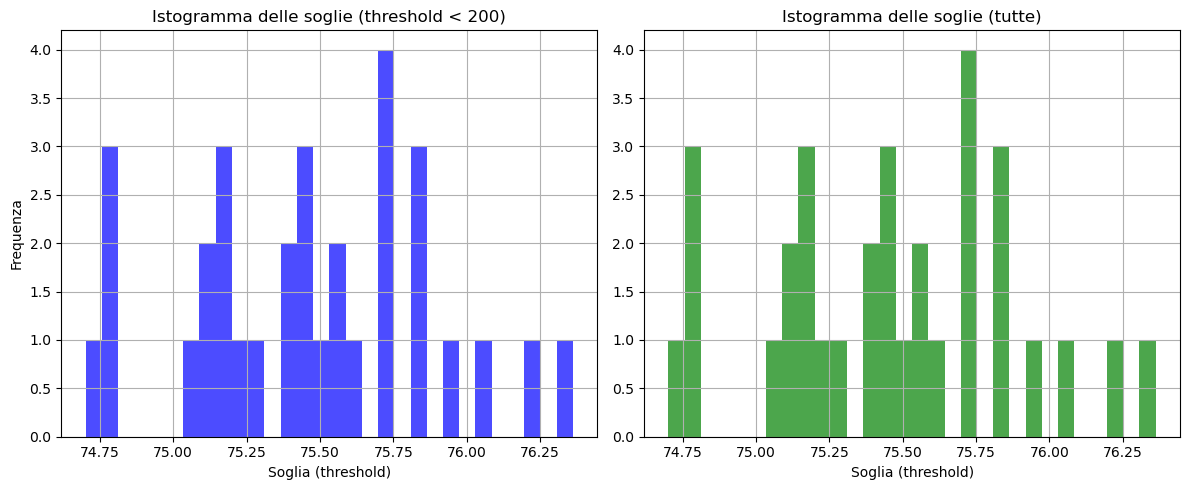

Soglia media: 75.46 ± 0.42


In [19]:
# Visualizza gli elementi della colonna 'threshold' del dataframe fit_df

thr_lt350 = fit_df.loc[fit_df["threshold"] < 200, "threshold"]


# affianca i due istogrammi (side-by-side)
fig_hist, axs_hist = plt.subplots(1, 2, figsize=(12, 5))

axs_hist[0].hist(thr_lt350.dropna(), bins=30, color='blue', alpha=0.7)
axs_hist[0].set_title("Istogramma delle soglie (threshold < 200)")
axs_hist[0].set_xlabel("Soglia (threshold)")
axs_hist[0].set_ylabel("Frequenza")
axs_hist[0].grid(True)

axs_hist[1].hist(fit_df["threshold"].dropna(), bins=30, color='green', alpha=0.7)
axs_hist[1].set_title("Istogramma delle soglie (tutte)")
axs_hist[1].set_xlabel("Soglia (threshold)")
axs_hist[1].grid(True)

plt.tight_layout()
plt.show()

# calcola media e deviazione standard delle soglie
mean_threshold = thr_lt350.mean()
std_threshold = thr_lt350.std()
print(f"Soglia media: {mean_threshold:.2f} ± {std_threshold:.2f}")


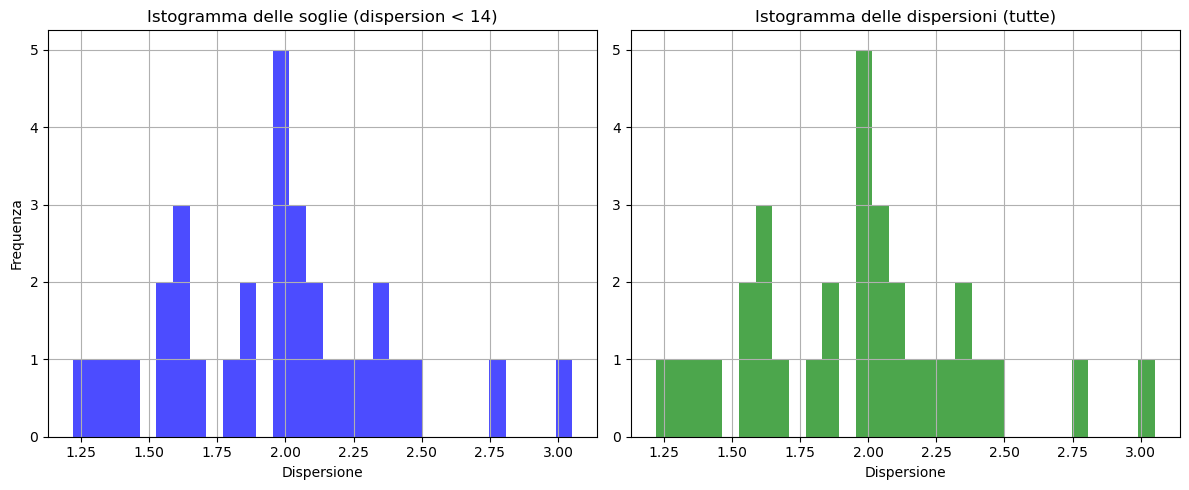

Dispersion < 14: mean = 1.97, std = 0.41


In [13]:
# Visualizza gli elementi della colonna 'threshold' del dataframe fit_df

#for v in fit_df["dispersion"]:
#    print(v)
thr_lt14 = fit_df.loc[fit_df["dispersion"] < 14, "dispersion"]



# affianca i due istogrammi (side-by-side)
fig_hist, axs_hist = plt.subplots(1, 2, figsize=(12, 5))

axs_hist[0].hist(thr_lt14.dropna(), bins=30, color='blue', alpha=0.7)
    
axs_hist[0].set_title("Istogramma delle soglie (dispersion < 14)")
axs_hist[0].set_xlabel("Dispersione")
axs_hist[0].set_ylabel("Frequenza")
axs_hist[0].grid(True)



axs_hist[1].hist(fit_df["dispersion"].dropna(), bins=30, color='green', alpha=0.7)
axs_hist[1].set_title("Istogramma delle dispersioni (tutte)")
axs_hist[1].set_xlabel("Dispersione")
axs_hist[1].grid(True)

plt.tight_layout()
plt.show()


# calcola media e deviazione standard della distribuzione di thr_lt14 se fit gaussiana
mean_dispersion = thr_lt14.mean()
std_dispersion = thr_lt14.std()

print(f"Dispersion < 14: mean = {mean_dispersion:.2f}, std = {std_dispersion:.2f}")
